<a href="https://colab.research.google.com/github/ReemaSaif/Applied-AI-Bootcamp-SDAIA/blob/main/WEEK%202/Projects/project%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Mental Health Crisis Index 2026 Analysis

## Scenario

The Global Mental Health Crisis Index 2026 is a cross-national dataset covering 92 countries across all six WHO regions, providing a comprehensive snapshot of the state of mental health worldwide as of 2025. It combines epidemiological, economic, policy, and digital behavior indicators into a single, analysis-ready file with no missing values.


## The Goal

To analyze global mental health patterns by examining how the COVID‑19 pandemic, socioeconomic conditions, digital behavior, and public policy intersect to influence mental health outcomes, access to care, and the overall effectiveness of mental health systems across countries.


## What is Inside The Dataset
Each row represents one country and includes 29 variables spanning:

* **Prevalence** — depression rate (%), anxiety rate (%), and estimated comorbidity
* **Crisis severity** — a composite mh_crisis_index score (0–100) and youth_mh_crisis_score
* **Healthcare capacity** — psychiatrists per 100k population, mental health budget as % of total health spending, per-capita mental health expenditure (USD)
* **Access & equity** — treatment gap (%), mental health policy/law existence (Yes/No)
* **Socioeconomic context** — GDP per capita, income group, population size
* **Digital environment** — average social media hours per day, internet penetration (%),
social media mental health risk category
* **COVID-19 impact** — estimated % increase in mental health burden post-pandemic
* **System quality** — an aggregated mh_system_score reflecting infrastructure and investment


## Key Questions

* Which countries and regions have the highest mental health burden?
* What factors are driving mental health outcomes?
* How do digital behaviors affect mental health?
* Where are the biggest care gaps?


## Scope
This analysis uses a dataset of 92 countries and 29 indicators across epidemiological, economic, policy, and digital behavior to examine variation in mental health outcomes. The notebook covers basic data cleaning, exploratory analysis, and statistical modeling to uncover regional patterns, inequalities in care access, and the impact of key factors. Also finish with key insights and recommendations.


#️Setup Code:

In [1]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
DATA_PATH = Path('../data/raw/')
OUTPUT_PATH = Path('../output/')

# Data Loading & Quick Validation:

We load the dataset and perform quick validation checks to ensure:
- Dataset is loaded correctly
- Column names and types are as expected


In [2]:
mental_health = pd.read_csv("/content/Global_Mental_Health_Crisis_Index_2026.csv")
mental_health.head()

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_policy_exists,mh_law_exists,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,97,1.1,16,700,20.4,86,9.5,No,No,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,96,1.2,18,600,32.8,85,9.4,No,No,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,95,1.4,22,1200,123.4,82,9.3,No,No,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,94,2.1,35,1000,15.9,82,9.3,No,No,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,94,1.6,28,1200,65.5,80,9.2,No,No,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [3]:
mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     object 
 1   iso3                                    92 non-null     object 
 2   region                                  92 non-null     object 
 3   income_group                            92 non-null     object 
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per100k                    92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_health                    92 non-null     float64
 9   mh_spend_usd_per_capita                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     int64  


In [4]:
mental_health.shape

(92, 29)

In [5]:
mental_health.columns

Index(['country', 'iso3', 'region', 'income_group', 'depression_pct',
       'anxiety_pct', 'suicide_rate_per100k', 'psychiatrists_per100k',
       'mh_budget_pct_health', 'mh_spend_usd_per_capita', 'treatment_gap_pct',
       'social_media_hours_daily', 'internet_penetration_pct',
       'gdp_per_capita_usd', 'population_millions', 'covid_mh_increase_pct',
       'youth_mh_crisis_score', 'mh_policy_exists', 'mh_law_exists',
       'mh_crisis_index', 'total_affected_millions',
       'psychiatrists_per_million', 'mh_investment_gap',
       'social_media_mental_health_risk',
       'depression_anxiety_comorbidity_est_pct', 'mh_system_score',
       'income_group_code', 'data_year', 'data_source'],
      dtype='object')

In [6]:
mental_health.dtypes

,0
country,object
iso3,object
region,object
income_group,object
depression_pct,float64
anxiety_pct,float64
suicide_rate_per100k,float64
psychiatrists_per100k,float64
mh_budget_pct_health,float64
mh_spend_usd_per_capita,float64


In [7]:
mental_health.describe()

,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.0
mean,4.402174,5.632609,11.559783,7.182283,3.758696,38.951087,58.934783,2.209783,73.750000,22231.608696,76.966304,49.630435,7.410870,58.293478,7.340870,71.822826,0.146359,2.201087,32.958696,2.923913,2025.0
std,0.754471,1.201657,9.825511,9.485814,2.960366,63.418593,27.884694,0.786711,24.262133,25685.337791,210.876926,16.320766,1.211434,13.637004,18.300855,94.858139,0.048522,0.377235,27.460854,1.008030,0.0
min,2.900000,3.800000,3.200000,0.020000,0.600000,0.100000,17.000000,0.100000,8.000000,600.000000,0.700000,26.000000,5.100000,36.000000,0.050000,0.200000,0.058000,1.450000,3.100000,1.000000,2025.0
25%,3.800000,4.800000,7.575000,0.500000,1.200000,0.725000,26.000000,1.600000,68.750000,3975.000000,9.475000,34.750000,6.300000,45.750000,0.857500,5.000000,0.106000,1.900000,9.025000,2.000000,2025.0
50%,4.400000,5.200000,9.800000,3.150000,2.850000,8.000000,64.500000,2.100000,82.500000,10150.000000,24.750000,48.000000,7.500000,58.000000,2.225000,31.500000,0.144500,2.200000,23.700000,3.000000,2025.0
75%,4.900000,6.100000,12.825000,12.450000,5.650000,49.750000,84.500000,2.800000,92.250000,33975.000000,59.375000,62.000000,8.400000,69.000000,5.977500,124.500000,0.179000,2.450000,55.875000,4.000000,2025.0
max,6.300000,9.300000,87.500000,54.900000,11.300000,320.000000,97.000000,4.800000,99.000000,106900.000000,1428.600000,86.000000,9.500000,87.000000,121.430000,549.000000,0.244000,3.150000,100.000000,4.000000,2025.0


### Initial Observations

* COVID‑19 led to a major increase in mental‑health across many countries.
* Many low‑income countries lack mental‑health laws and policies.
* Treatment gaps are extremely high in low‑income countries, often exceeding 90%.

Next, we check for missing values and duplicates.

# Data Cleaning:

We check for:
- Missing values
- Duplicate records


In [8]:
mental_health.isnull().sum()

,0
country,0
iso3,0
region,0
income_group,0
depression_pct,0
anxiety_pct,0
suicide_rate_per100k,0
psychiatrists_per100k,0
mh_budget_pct_health,0
mh_spend_usd_per_capita,0


In [9]:
mental_health.duplicated().sum()

np.int64(0)

### Cleaning Summary

- No missing values
- No duplicate records
- Dataset is clean and ready for analysis

# **Use Cases**

### **Visualization & dashboards** — build regional heatmaps, scatter plots, or choropleth maps

**Regional Crisis:**

Show how mental health crisis severity varies by region.

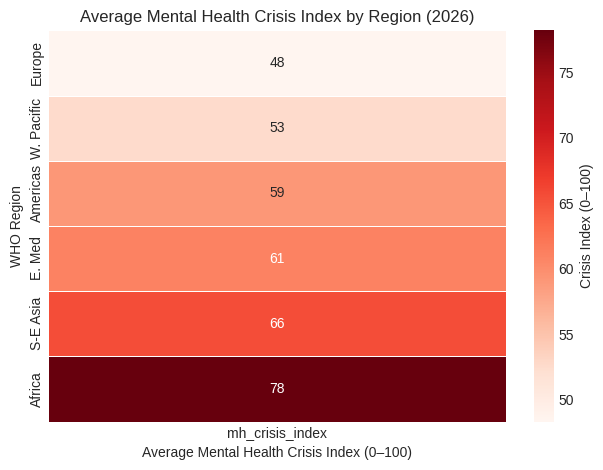

In [10]:
region_crisis = mental_health.groupby('region')['mh_crisis_index'].mean().reset_index()
region_crisis = region_crisis.sort_values('mh_crisis_index', ascending=True)

heatmap_data = region_crisis.set_index('region')

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='Reds',
    linewidths=.5,
    cbar_kws={'label': 'Crisis Index (0–100)'}
)

plt.title('Average Mental Health Crisis Index by Region (2026)')
plt.xlabel('Average Mental Health Crisis Index (0–100)')
plt.ylabel('WHO Region')
plt.tight_layout()
plt.show()

From the heatmap **Africa** shows the **highest** average Mental Health Crisis Index  by 78. As a result, Africa stands out as the region requiring the most urgent and targeted intervention.  While **Europe** has the **lowest** average crisis index by 48. This does not imply that Europe is free from mental‑health issues; rather, it indicates that the relative severity of mental‑health crises is lower compared to other regions.

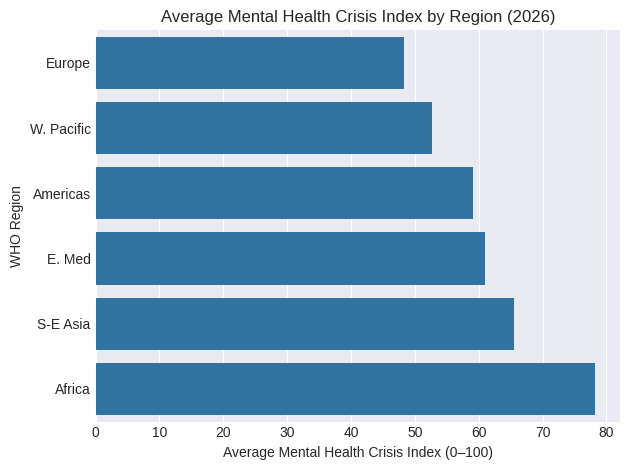

In [11]:
region_crisis = mental_health.groupby('region')['mh_crisis_index'].mean().reset_index().sort_values('mh_crisis_index')

sns.barplot(data=region_crisis, x='mh_crisis_index', y='region')
plt.xlabel('Average Mental Health Crisis Index (0–100)')
plt.ylabel('WHO Region')
plt.title('Average Mental Health Crisis Index by Region (2026)')
plt.tight_layout()
plt.show()

From the barplot **Africa** shows the **highest** average Mental Health Crisis Index (around 75–80). As a result, Africa stands out as the region requiring the most urgent and targeted intervention.  While **Europe** has the **lowest** average crisis index (around 45–50). This does not imply that Europe is free from mental‑health issues; rather, it indicates that the relative severity of mental‑health crises is lower compared to other regions.

### **Social media & mental health** — explore the relationship between screen time and depression/anxiety rates


**Screen Time Vs Depression/Anxiety:**

Explore the relationship between digital behavior (screen time) and mental‑health outcomes (depression/anxiety).

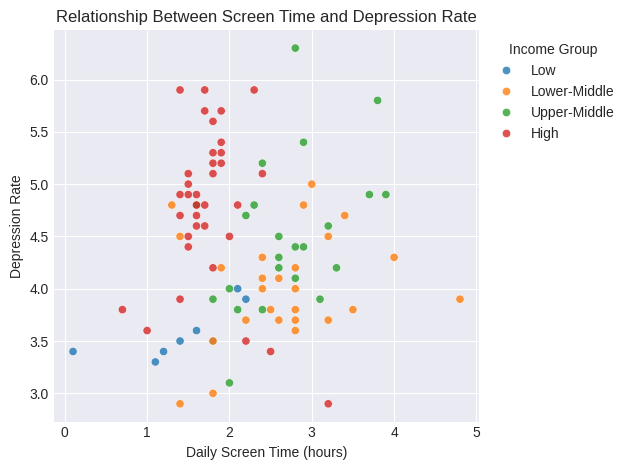

In [12]:
sns.scatterplot(
    data=mental_health,
    x='social_media_hours_daily',
    y='depression_pct',
    alpha=0.8,
    hue='income_group',
)

plt.title('Relationship Between Screen Time and Depression Rate')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Depression Rate')
plt.legend(title='Income Group', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

The scatter plot shows that the data points are widely scattered, indicating **no strong linear relationship between daily screen time and depression rates**. In other words it means that the screen time is not a strong predictor of depression. However, higher‑income groups consistently show higher depression levels, suggesting **socioeconomic factors** may influence depression more than screen time does.


In [13]:
corr = mental_health['social_media_hours_daily'].corr(
    mental_health['depression_pct']
)

print("The Correlation Coefficient (r) is:" , round(corr,3))

The Correlation Coefficient (r) is: 0.025


Because  the value of r = 0.025 is extremely close to zero, there is **no meaningful linear relationship between daily screen time and depression rate**. In other words, screen time does not predict depression in this dataset.

### **COVID-19 aftermath** — analyze which regions saw the largest pandemic-era mental health surge


**COVID-19 Aftermath by Region:**

Analyze which regions saw the largest post‑COVID increase in mental health burden.

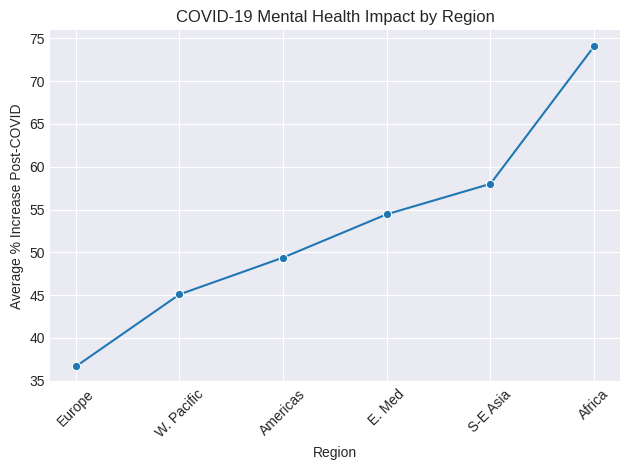

In [14]:
region_covid = mental_health.groupby('region')['covid_mh_increase_pct'].mean().reset_index().sort_values('covid_mh_increase_pct')

sns.lineplot(
    data=region_covid,
    x='region',
    y='covid_mh_increase_pct',
    marker='o'
)

plt.xticks(rotation=45)
plt.ylabel('Average % Increase Post-COVID')
plt.xlabel('Region')
plt.title('COVID-19 Mental Health Impact by Region')
plt.tight_layout()
plt.show()

The line plot shows a clear **upward trend,** with the average post COVID-19 increase in mental health burden rising steadily from Europe to Africa. **Europe** records the **lowest** increase, while **Africa** shows the **highest**. This pattern indicates that the psychological impact of the pandemic was **uneven across regions**, with some areas such as Africa experiencing significantly greater mental health challenges than others.

### **Policy analysis** — examine the impact of mental health laws and budgets on treatment gaps


1. Do countries with mental health laws have lower treatment gaps?

**Hypotheses:**
* Null Hypothesis (H₀): There is no difference in treatment gaps between countries with and without mental health laws.

* Alternative Hypothesis (H₁): Countries with mental health laws have lower treatment gaps than those without.


In [15]:
print(mental_health.groupby('mh_law_exists')['treatment_gap_pct'].mean())

mh_law_exists
No     89.458333
Yes    48.161765
Name: treatment_gap_pct, dtype: float64


* This already shows a large difference between the mean treatment gap in countries WITH laws compared to countries WITHOUT laws.

* The mean treatment gap is 41 percentage points lower in countries with laws. [89 − 48 = 41 percentage points]

In [16]:
mental_health['Law_binary'] = mental_health['mh_law_exists'].map({'Yes': 1, 'No': 0})

with_law = mental_health[mental_health["Law_binary"] == 1]["treatment_gap_pct"]
without_law = mental_health[mental_health["Law_binary"] == 0]["treatment_gap_pct"]

t_stat, p_value = stats.ttest_ind(with_law, without_law, equal_var=False)

print("The P-value is:", p_value)

The P-value is: 8.077055902824954e-22


Since the p-value is extremely close to zero = 8.077055902824954e-22 < 0.05, we **reject the null hypothesis (H₀)**. There is **strong statistical evidence** that countries with mental health laws have significantly **lower** treatment gaps than countries without such laws.



2. Examine the impact of mental health laws and budgets on treatment gaps?

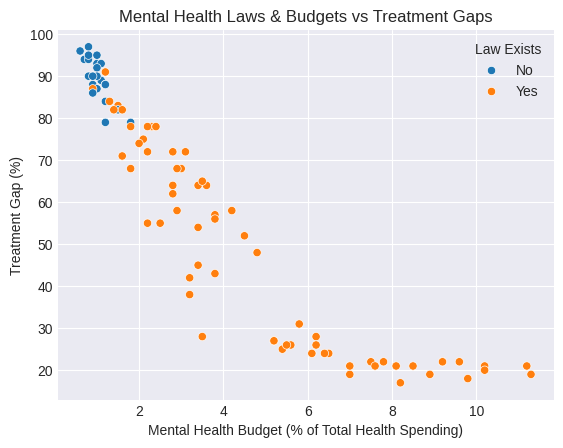

In [17]:
sns.scatterplot(
    data=mental_health,
    x='mh_budget_pct_health',
    y='treatment_gap_pct',
    hue='mh_law_exists',
)

plt.title("Mental Health Laws & Budgets vs Treatment Gaps")
plt.xlabel("Mental Health Budget (% of Total Health Spending)")
plt.ylabel("Treatment Gap (%)")
plt.legend(title="Law Exists")
plt.show()

The scatter plot shows a **strong negative relationship** **between mental health budget and treatment gap.** As mental health budgets increase, treatment gaps consistently decrease, indicating that greater financial investment improves access to care. Additionally, countries with mental health laws appear to use their budgets more effectively, converting funding into reduced treatment gaps more efficiently than countries without such laws.


### **Inequality research** — compare high-income vs. low-income country disparities in care access


Compare care access and system quality between income groups.

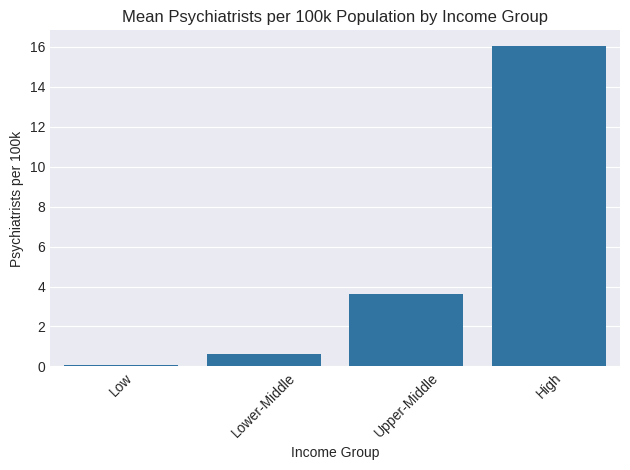

In [18]:
group_means = mental_health.groupby("income_group")["psychiatrists_per100k"].mean().reset_index().sort_values("psychiatrists_per100k")

sns.barplot(
    data=group_means,
    x="income_group",
    y="psychiatrists_per100k",
)

plt.title("Mean Psychiatrists per 100k Population by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Psychiatrists per 100k")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows a **strong positive relationship between national income level and the availability of psychiatrists.** Higher‑income countries have significantly stronger mental‑health systems, whereas low‑income countries experience critical shortages, with nearly no psychiatrists available per 100k people.

### **Clustering & segmentation** — group countries by mental health burden, system strength, or income level


Mental Health Burden Score by Region.

In [19]:
mental_health["mh_burden_score"] = mental_health[[
    "depression_pct",
    "anxiety_pct",
    "depression_anxiety_comorbidity_est_pct"
]].mean(axis=1)

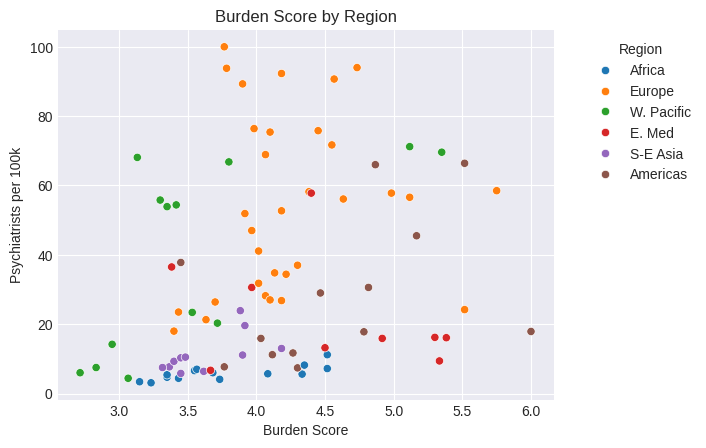

In [20]:
sns.scatterplot(
    data=mental_health,
    x="mh_burden_score",
    y="mh_system_score",
    hue="region",
)

plt.title("Burden Score by Region")
plt.xlabel("Burden Score")
plt.ylabel("Psychiatrists per 100k")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The scatter plot shows a clear **global inequality pattern**:
Africa and parts of S‑E Asia face high mental‑health burden with extremely limited psychiatric capacity, while Europe and high‑income W. Pacific countries have strong mental‑health systems and lower burden levels.The Americas and E. Med regions fall in the middle, reflecting partial system development and rising burden.

### **Regression & prediction** — model the crisis index from economic, digital, and policy variables


Model the crisis index from digital variables.

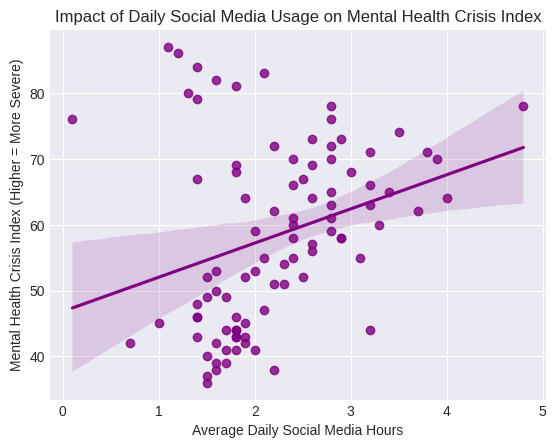

In [21]:
sns.regplot(
    data=mental_health,
    x='social_media_hours_daily',
    y='mh_crisis_index',
    color='purple',
)

plt.title('Impact of Daily Social Media Usage on Mental Health Crisis Index')
plt.xlabel('Average Daily Social Media Hours')
plt.ylabel('Mental Health Crisis Index (Higher = More Severe)')
plt.show()

The regression analysis shows a **strong positive association between daily social media usage and the mental health crisis index**, indicating that countries with higher social media exposure tend to experience more severe mental‑health crises.

# Summary & Next Steps:


### Key Findings

* Mental health crisis varies widely across countries
* COVID-19 significantly worsened mental health globally
* Policies and funding reduce treatment gaps
* Digital exposure has a moderate effect on mental health


### Summary

The dataset provides a global view of mental health burden, system capacity, digital behavior, and socioeconomic context across 92 countries. Clear patterns emerge: stronger systems and higher investment reduce crisis severity, while weak systems, high treatment gaps, and low income are associated with severe mental health crises. Digital behavior contributes but is not the main driver.


### Limitations

* The dataset is compiled from multiple sources aligned to 2025, which may lead to timing inconsistencies.

* Correlations cannot prove causation.

* The crisis index is a composite metric with subjective weighting.



# **Conclusion:**

The analysis indicates that the global mental‑health crisis is **unevenly distributed and strongly shaped by inequality**. Stronger systems with better funding and policies show lower crisis levels, while weaker systems face higher pressure. **Digital behavior and COVID-19** contribute to increased pressure on mental health, but they play a smaller role compared to underlying structural factors.




Overall, the findings point to a central conclusion that mental health outcomes are not just medical issues but are deeply shaped by economic capacity, policy decisions, and access to care.




